# 1. EDA: Indeed Hiring Lab Sectors + Headline
Seasonally unadjusted

#### Combining the 2 dataframes and then visualizing the data, finding similarities among variables, and seeing how the data interacts with itself.
#### 

In [14]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import glob

In [15]:
# === Step 1: Load and Inspect Dataset for Sectoral===
# Was working to get the average of the overlapping NEW and TOTAL job postings with overlapping dateString
# Moving on for now for sake of speed
DATA_PATH_sectoral = "C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted"
csv_files_sectoral = glob.glob(os.path.join(DATA_PATH_sectoral, "*.csv"))

dataframes = []

for file in csv_files_sectoral:
    # Read each CSV file
    df_temp = pd.read_csv(file)    
    # Add a column to identify which file the data came from
    df_temp['source_file'] = os.path.basename(file)
    
    # Add to our list of dataframes
    dataframes.append(df_temp)
    
    print(f"Loaded {file}: {df_temp.shape[0]} rows, {df_temp.shape[1]} columns")

# Combine all dataframes using pd.concat()
sectoral_df = pd.concat(dataframes, ignore_index=True)

print(f"\nCombined dataframe shape: {sectoral_df.shape}")
print(f"Total rows: {len(sectoral_df)}")
print(f"Total columns: {len(sectoral_df.columns)}")


print("Data types: \n", sectoral_df.dtypes, "\n ---")
print("Data info: \n", sectoral_df.info(), "\n ---")

sectoral_df = sectoral_df[sectoral_df['postingType'] != 'NEW'].copy()

sectoral_df


<>:4: SyntaxWarning: invalid escape sequence '\g'
<>:4: SyntaxWarning: invalid escape sequence '\g'
C:\Users\rojas\AppData\Local\Temp\ipykernel_35672\334529888.py:4: SyntaxWarning: invalid escape sequence '\g'
  DATA_PATH_sectoral = "C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted"


Loaded C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted\accounting_admin-assist_architecture-arts+entertainment_banking+finance_childcare_civilengineering.csv: 14406 rows, 9 columns
Loaded C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted\cleaning+sanitation_community+social-service_construction_customer-service_data-analytics_dental_driving.csv: 14406 rows, 9 columns
Loaded C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted\education-instruction_electrical-engineering_food-prep+service_hospitality+tourism_human-resources_IT-infrastructure_IT-systems.csv: 14406 rows, 9 columns
Loaded C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted\industrial-engineering_installation+maintenance_legal_loading+stocking_logistic-support_management_marketing.csv: 14406 rows, 9 columns
Loaded C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted\m

,__typename,dateString,countryCode,countryName,sectorCode,sectorName,postingType,value,source_file
0,HiringLabSectoralPosting,2020-02-01,US,United States,accounting,Accounting,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
1,HiringLabSectoralPosting,2020-02-01,US,United States,admin,Administrative Assistance,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
2,HiringLabSectoralPosting,2020-02-01,US,United States,arch,Architecture,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
3,HiringLabSectoralPosting,2020-02-01,US,United States,arts,Arts & Entertainment,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
4,HiringLabSectoralPosting,2020-02-01,US,United States,childcare,Childcare,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
...,...,...,...,...,...,...,...,...,...
92605,HiringLabSectoralPosting,2025-09-18,US,United States,therapy,Therapy,TOTAL,195.99,sports_therapy_veterinary.csv
92606,HiringLabSectoralPosting,2025-09-18,US,United States,veterinary,Veterinary,TOTAL,148.98,sports_therapy_veterinary.csv
92607,HiringLabSectoralPosting,2025-09-19,US,United States,sports,Sports,TOTAL,153.11,sports_therapy_veterinary.csv
92608,HiringLabSectoralPosting,2025-09-19,US,United States,therapy,Therapy,TOTAL,195.85,sports_therapy_veterinary.csv


In [16]:
# === Step 2: Load and Inspect Dataset for Headline ===
DATA_PATH_headline = "C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Total_US_Market\job-postings-headline-index-no-seasonal-adjustement.csv"
headline_df = pd.read_csv(DATA_PATH_headline)
print("Data types: \n", headline_df.dtypes, "\n ---")
print("Data info: \n", headline_df.info(), "\n ---")
headline_df['source_file'] = 'job-postings-headline-index-no-seasonal-adjustement.csv'
headline_df['sectorName'] = 'Headline'
headline_df['sectorCode'] = 'Headline'
headline_df

Data types: 
 __typename      object
dateString      object
countryCode     object
countryName     object
postingType     object
value          float64
dtype: object 
 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2058 entries, 0 to 2057
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   __typename   2058 non-null   object 
 1   dateString   2058 non-null   object 
 2   countryCode  2058 non-null   object 
 3   countryName  2058 non-null   object 
 4   postingType  2058 non-null   object 
 5   value        2058 non-null   float64
dtypes: float64(1), object(5)
memory usage: 96.6+ KB
Data info: 
 None 
 ---


<>:2: SyntaxWarning: invalid escape sequence '\g'
<>:2: SyntaxWarning: invalid escape sequence '\g'
C:\Users\rojas\AppData\Local\Temp\ipykernel_35672\2761932370.py:2: SyntaxWarning: invalid escape sequence '\g'
  DATA_PATH_headline = "C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Total_US_Market\job-postings-headline-index-no-seasonal-adjustement.csv"


,__typename,dateString,countryCode,countryName,postingType,value,source_file,sectorName,sectorCode
0,HiringLabNationalPosting,2020-02-01,US,United States,TOTAL,100.00,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
1,HiringLabNationalPosting,2020-02-02,US,United States,TOTAL,100.06,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
2,HiringLabNationalPosting,2020-02-03,US,United States,TOTAL,100.09,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
3,HiringLabNationalPosting,2020-02-04,US,United States,TOTAL,100.18,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
4,HiringLabNationalPosting,2020-02-05,US,United States,TOTAL,100.29,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
...,...,...,...,...,...,...,...,...,...
2053,HiringLabNationalPosting,2025-09-15,US,United States,TOTAL,108.51,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
2054,HiringLabNationalPosting,2025-09-16,US,United States,TOTAL,108.47,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
2055,HiringLabNationalPosting,2025-09-17,US,United States,TOTAL,108.45,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
2056,HiringLabNationalPosting,2025-09-18,US,United States,TOTAL,108.39,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline


In [17]:
# === Step 3: Combine the dataframes for Headline and Sectoral ===
combined_df = pd.merge(headline_df, sectoral_df, on=['sectorName','sectorCode','source_file','dateString', 'countryCode', 'postingType','countryName','__typename','value'], how='outer')

print(f"\nCombined dataframe shape: {combined_df.shape}")
print(f"Total rows: {len(combined_df)}")
print(f"Total columns: {len(combined_df.columns)}")


print("Data types: \n", combined_df.dtypes, "\n ---")
print("Data info: \n", combined_df.info(), "\n ---")

combined_df



Combined dataframe shape: (94668, 9)
Total rows: 94668
Total columns: 9
Data types: 
 __typename      object
dateString      object
countryCode     object
countryName     object
postingType     object
value          float64
source_file     object
sectorName      object
sectorCode      object
dtype: object 
 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94668 entries, 0 to 94667
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   __typename   94668 non-null  object 
 1   dateString   94668 non-null  object 
 2   countryCode  94668 non-null  object 
 3   countryName  94668 non-null  object 
 4   postingType  94668 non-null  object 
 5   value        94668 non-null  float64
 6   source_file  94668 non-null  object 
 7   sectorName   94668 non-null  object 
 8   sectorCode   94668 non-null  object 
dtypes: float64(1), object(8)
memory usage: 6.5+ MB
Data info: 
 None 
 ---


,__typename,dateString,countryCode,countryName,postingType,value,source_file,sectorName,sectorCode
0,HiringLabSectoralPosting,2020-02-01,US,United States,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...,Accounting,accounting
1,HiringLabSectoralPosting,2020-02-02,US,United States,TOTAL,99.97,accounting_admin-assist_architecture-arts+ente...,Accounting,accounting
2,HiringLabSectoralPosting,2020-02-03,US,United States,TOTAL,99.89,accounting_admin-assist_architecture-arts+ente...,Accounting,accounting
3,HiringLabSectoralPosting,2020-02-04,US,United States,TOTAL,99.81,accounting_admin-assist_architecture-arts+ente...,Accounting,accounting
4,HiringLabSectoralPosting,2020-02-05,US,United States,TOTAL,99.82,accounting_admin-assist_architecture-arts+ente...,Accounting,accounting
...,...,...,...,...,...,...,...,...,...
94663,HiringLabSectoralPosting,2025-09-15,US,United States,TOTAL,148.49,sports_therapy_veterinary.csv,Veterinary,veterinary
94664,HiringLabSectoralPosting,2025-09-16,US,United States,TOTAL,148.85,sports_therapy_veterinary.csv,Veterinary,veterinary
94665,HiringLabSectoralPosting,2025-09-17,US,United States,TOTAL,149.01,sports_therapy_veterinary.csv,Veterinary,veterinary
94666,HiringLabSectoralPosting,2025-09-18,US,United States,TOTAL,148.98,sports_therapy_veterinary.csv,Veterinary,veterinary


In [27]:
#better since were just stacking the dataframes
combined_df = pd.concat([headline_df, sectoral_df], ignore_index=True)
combined_df

,__typename,dateString,countryCode,countryName,postingType,value,source_file,sectorName,sectorCode
0,HiringLabNationalPosting,2020-02-01,US,United States,TOTAL,100.00,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
1,HiringLabNationalPosting,2020-02-02,US,United States,TOTAL,100.06,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
2,HiringLabNationalPosting,2020-02-03,US,United States,TOTAL,100.09,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
3,HiringLabNationalPosting,2020-02-04,US,United States,TOTAL,100.18,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
4,HiringLabNationalPosting,2020-02-05,US,United States,TOTAL,100.29,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
...,...,...,...,...,...,...,...,...,...
94663,HiringLabSectoralPosting,2025-09-18,US,United States,TOTAL,195.99,sports_therapy_veterinary.csv,Therapy,therapy
94664,HiringLabSectoralPosting,2025-09-18,US,United States,TOTAL,148.98,sports_therapy_veterinary.csv,Veterinary,veterinary
94665,HiringLabSectoralPosting,2025-09-19,US,United States,TOTAL,153.11,sports_therapy_veterinary.csv,Sports,sports
94666,HiringLabSectoralPosting,2025-09-19,US,United States,TOTAL,195.85,sports_therapy_veterinary.csv,Therapy,therapy


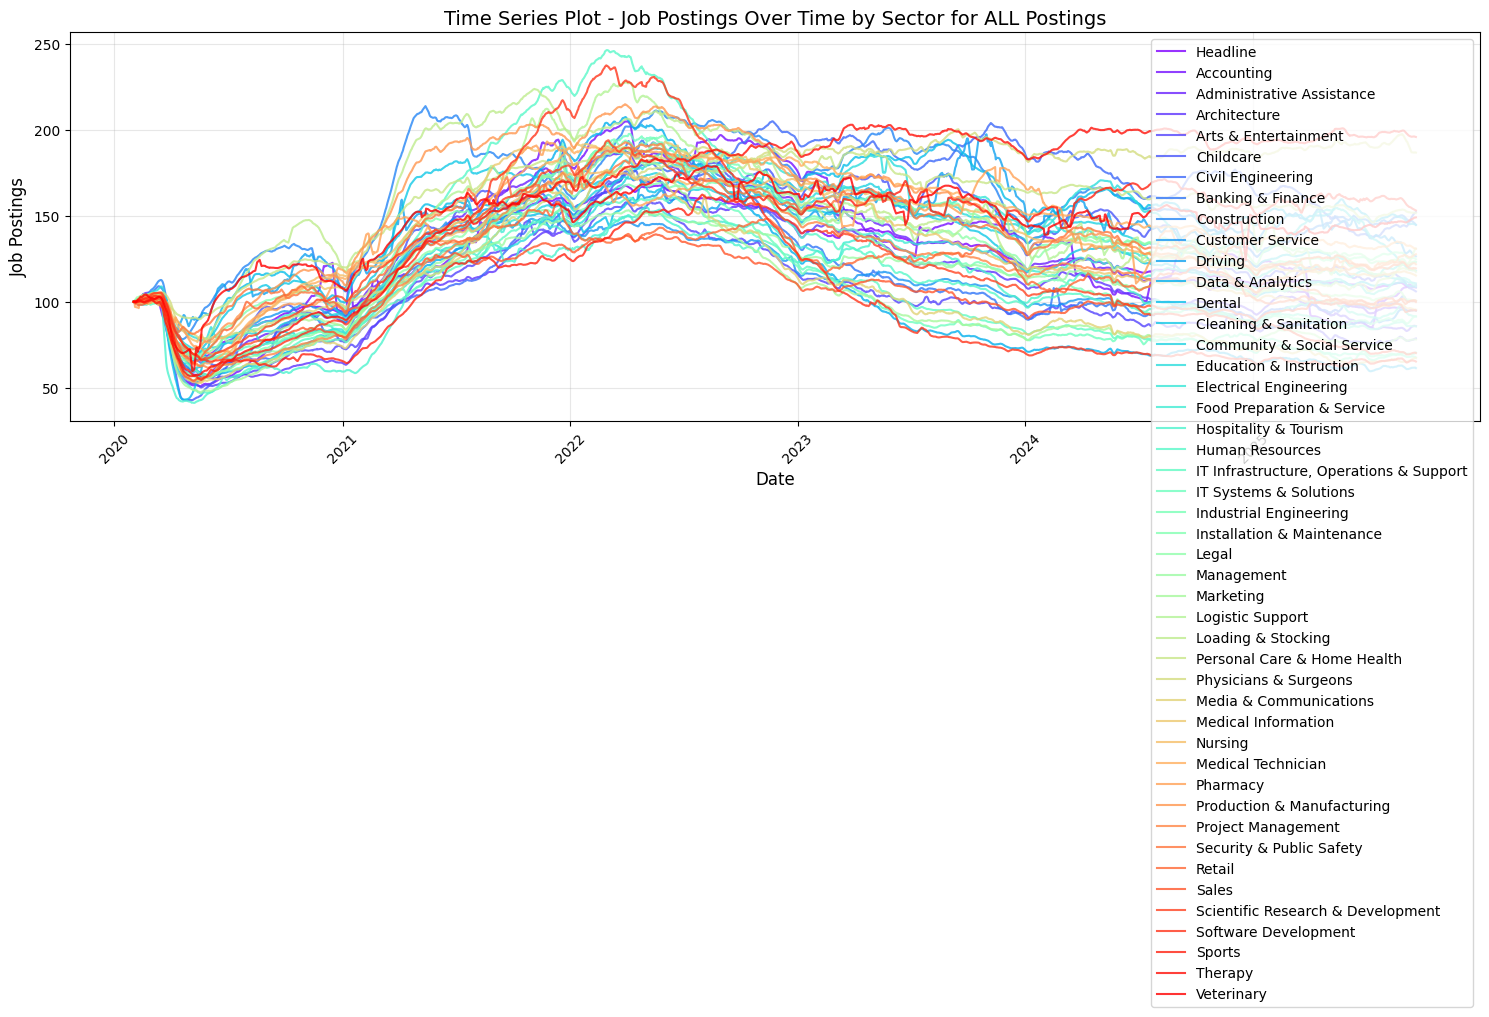

In [19]:
# Now let's create a simple time-series plot
# First, we need to convert the dateString column to a datetime object using pd.to_datetime
combined_df['dateString'] = pd.to_datetime(combined_df['dateString'])

# Set up the plot
plt.figure(figsize=(15, 8))

sectors = combined_df['sectorName'].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(sectors)))

for i, sector in enumerate(sectors):
    sector_data = combined_df[combined_df['sectorName'] == sector]
    plt.plot(sector_data['dateString'], sector_data['value'], label=sector, color=colors[i], linewidth=1.5, alpha=0.8)

plt.title('Time Series Plot - Job Postings Over Time by Sector for ALL Postings', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Job Postings', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

Now we want to understand what sector has the most influence on the headline dataset from the job posting datasets

In [20]:
# to do this, convert dateString->datetime and make pivot table
combined_df['dateString'] = pd.to_datetime(combined_df['dateString'])

pivot_df = combined_df.pivot_table(
    index='dateString',
    columns='sectorName',
    values='value',
    aggfunc='mean'
)
print("")
# === Step 2: Calculate the correlation matrix ===


correlation_matrix = pivot_df.corr()

print(f"\nCorrelation matrix shape: {correlation_matrix.shape}")
print("\nCorrelation matrix:")
print(correlation_matrix)

# === Step 3: Extract correlations with headline ===
headline_correlations = correlation_matrix['Headline'].drop('Headline')

headline_correlations_sorted = headline_correlations.abs().sort_values(ascending=False)

print("\nSector correlations with Headline (sorted by strength):")
print(headline_correlations_sorted)

print("\nDetailed correlations with Headline:")
detailed_correlations = headline_correlations.sort_values(ascending=False)
print(detailed_correlations)



Correlation matrix shape: (46, 46)

Correlation matrix:
sectorName                               Accounting  \
sectorName                                            
Accounting                                 1.000000   
Administrative Assistance                  0.949189   
Architecture                               0.928967   
Arts & Entertainment                       0.922124   
Banking & Finance                          0.896994   
Childcare                                  0.850038   
Civil Engineering                          0.666509   
Cleaning & Sanitation                      0.838609   
Community & Social Service                 0.877244   
Construction                               0.748908   
Customer Service                           0.828390   
Data & Analytics                           0.827007   
Dental                                     0.657778   
Driving                                    0.732483   
Education & Instruction                    0.707168   
Electri

In [21]:
# === Step 2b: Variance Inflation Factor (VIF) analysis to detect multicollinearity ===
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1) Prepare data for VIF:
#    - we work on a copy of pivot_df
#    - drop columns that are all NaN or have zero variance
vif_df = pivot_df.copy()

# Drop columns with all NaN
vif_df = vif_df.dropna(axis=1, how="all")

# Forward-fill then back-fill to handle gaps (time-series friendly)
vif_df = vif_df.ffill().bfill()

# Drop columns that still contain NaN (edge cases)
vif_df = vif_df.dropna(axis=1, how="any")

# Drop constant columns (zero variance) – VIF is undefined there
constant_cols = vif_df.columns[vif_df.nunique() <= 1]
if len(constant_cols) > 0:
    print(f"Dropping constant columns from VIF analysis: {list(constant_cols)}")
    vif_df = vif_df.drop(columns=constant_cols)

print(f"VIF DataFrame shape after cleaning: {vif_df.shape}")

# 2) Compute VIF for each column (each sector, including Headline)
vif_values = []
cols = vif_df.columns.tolist()

for i in range(len(cols)):
    vif = variance_inflation_factor(vif_df.values, i)
    vif_values.append({"sectorName": cols[i], "VIF": vif})

vif_result_df = pd.DataFrame(vif_values).sort_values("VIF", ascending=False)

print("\n=== VIF RESULTS (sorted descending) ===")
print(vif_result_df)

# 3) Basic interpretation / quick filters
high_vif_threshold = 10.0       # common rule-of-thumb
very_high_vif_threshold = 50.0  # very strong multicollinearity

high_vif = vif_result_df[vif_result_df["VIF"] >= high_vif_threshold]
very_high_vif = vif_result_df[vif_result_df["VIF"] >= very_high_vif_threshold]

print(f"\nNumber of features with VIF >= {high_vif_threshold}: {len(high_vif)}")
print(f"Number of features with VIF >= {very_high_vif_threshold}: {len(very_high_vif)}")

print("\nTop 10 highest VIF features:")
print(vif_result_df.head(10))

# 4) (Optional) If you want to see VIF excluding the Headline itself:
if "Headline" in vif_df.columns:
    vif_no_headline = vif_df.drop(columns=["Headline"])
    cols_no_h = vif_no_headline.columns.tolist()
    vif_values_no_h = []
    for i in range(len(cols_no_h)):
        vif = variance_inflation_factor(vif_no_headline.values, i)
        vif_values_no_h.append({"sectorName": cols_no_h[i], "VIF": vif})
    vif_result_no_headline_df = (
        pd.DataFrame(vif_values_no_h)
        .sort_values("VIF", ascending=False)
    )
    print("\n=== VIF RESULTS EXCLUDING HEADLINE (sorted descending) ===")
    print(vif_result_no_headline_df.head(20))
else:
    vif_result_no_headline_df = None

# 5) Save VIF output for use in the EDA report
vif_output_base = r"C:\git\SwYtch-Team-Monkey\Processed_Data\Indeed_Hiring_Lab\csv"
os.makedirs(vif_output_base, exist_ok=True)

vif_csv_path = os.path.join(vif_output_base, "indeed_headline_and_sectors_vif_full.csv")
vif_result_df.to_csv(vif_csv_path, index=False)
print(f"\nSaved full VIF results to: {vif_csv_path}")

if vif_result_no_headline_df is not None:
    vif_no_headline_csv_path = os.path.join(
        vif_output_base, "indeed_headline_and_sectors_vif_excluding_headline.csv"
    )
    vif_result_no_headline_df.to_csv(vif_no_headline_csv_path, index=False)
    print(f"Saved VIF results (excluding Headline) to: {vif_no_headline_csv_path}")

VIF DataFrame shape after cleaning: (2058, 46)

=== VIF RESULTS (sorted descending) ===
                                 sectorName           VIF
17                                 Headline  1.879994e+06
23               Installation & Maintenance  4.666343e+04
27                               Management  4.449677e+04
37                       Project Management  3.832583e+04
8                Community & Social Service  3.460633e+04
31                       Medical Technician  3.394693e+04
16               Food Preparation & Service  3.217246e+04
1                 Administrative Assistance  2.249335e+04
32                                  Nursing  2.220064e+04
22                   Industrial Engineering  2.015200e+04
36               Production & Manufacturing  1.961359e+04
7                     Cleaning & Sanitation  1.805783e+04
39                                    Sales  1.681500e+04
11                         Data & Analytics  1.394446e+04
20  IT Infrastructure, Operations & Suppor

<Figure size 1200x600 with 0 Axes>

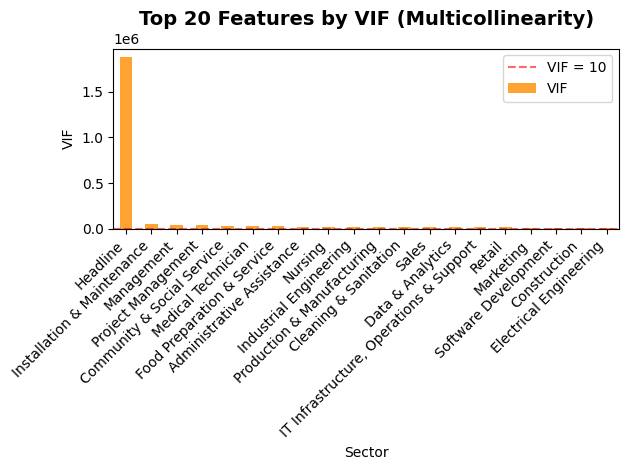

In [22]:
# Plot top 20 highest VIF features
plt.figure(figsize=(12, 6))
vif_result_df.head(20).plot(
    x="sectorName",
    y="VIF",
    kind="bar",
    legend=False,
    color="darkorange",
    alpha=0.8,
)
plt.axhline(10, color="red", linestyle="--", alpha=0.6, label="VIF = 10")
plt.title("Top 20 Features by VIF (Multicollinearity)", fontsize=14, fontweight="bold")
plt.xlabel("Sector")
plt.ylabel("VIF")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.legend()
plt.show()

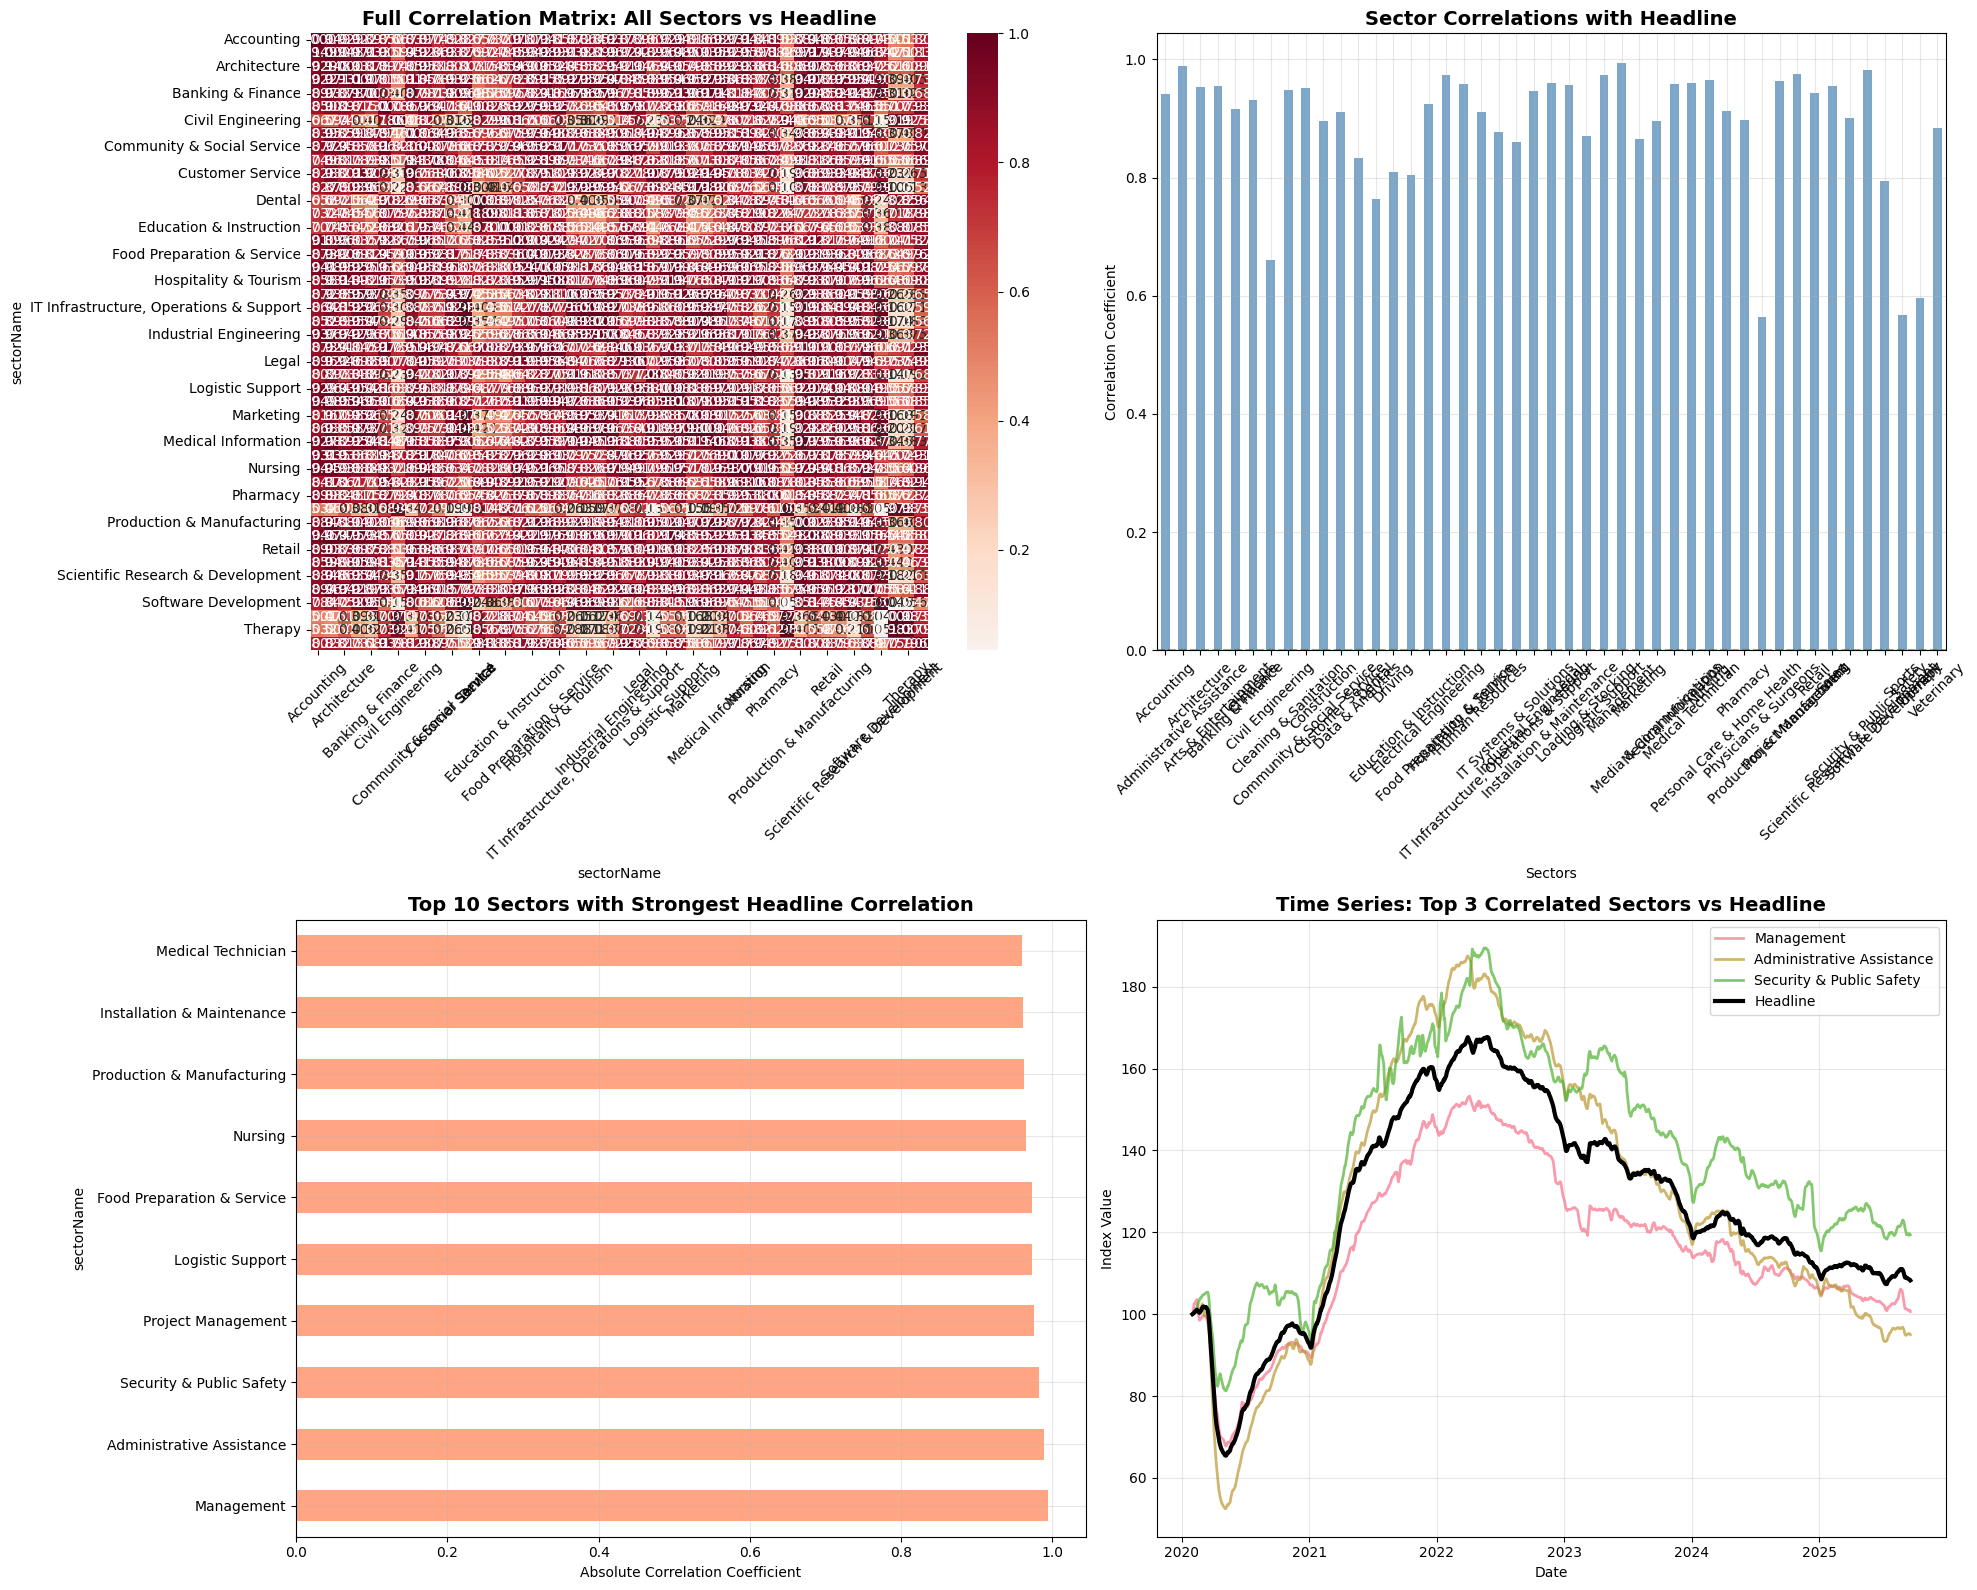

In [23]:
# === Step 4: Create beautiful visualizations ===
# set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create a comprehensive figure with multiple plots
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Plot 1: Correlation heatmap (full matrix)
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.3f', ax=axes[0,0])
axes[0,0].set_title('Full Correlation Matrix: All Sectors vs Headline', fontsize=14, fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].tick_params(axis='y', rotation=0)

# Plot 2: Bar chart of headline correlations
headline_correlations.plot(kind='bar', ax=axes[0,1], color='steelblue', alpha=0.7)
axes[0,1].set_title('Sector Correlations with Headline', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Sectors')
axes[0,1].set_ylabel('Correlation Coefficient')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Top 10 strongest correlations (absolute value)
top_10 = headline_correlations.abs().nlargest(10)
top_10.plot(kind='barh', ax=axes[1,0], color='coral', alpha=0.7)
axes[1,0].set_title('Top 10 Sectors with Strongest Headline Correlation', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Absolute Correlation Coefficient')
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Time series of top 3 correlated sectors vs headline
top_3_sectors = headline_correlations.abs().nlargest(3).index
for sector in top_3_sectors:
    axes[1,1].plot(pivot_df.index, pivot_df[sector], label=f'{sector}', alpha=0.7, linewidth=2)

axes[1,1].plot(pivot_df.index, pivot_df['Headline'], label='Headline', color='black', linewidth=3)
axes[1,1].set_title('Time Series: Top 3 Correlated Sectors vs Headline', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Index Value')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# === Step 5: Statistical summary ===
print("=== COLLINEARITY ANALYSIS SUMMARY ===")
print(f"Total sectors analyzed: {len(headline_correlations)}")
print(f"Date range: {pivot_df.index.min().strftime('%Y-%m-%d')} to {pivot_df.index.max().strftime('%Y-%m-%d')}")
print(f"Number of data points: {len(pivot_df)}")

print(f"\n=== TOP 5 STRONGEST POSITIVE CORRELATIONS ===")
positive_corr = headline_correlations[headline_correlations > 0].nlargest(5)
for sector, corr in positive_corr.items():
    print(f"{sector}: {corr:.4f}")

print(f"\n=== TOP 5 STRONGEST NEGATIVE CORRELATIONS ===")
negative_corr = headline_correlations[headline_correlations < 0].nsmallest(5)
for sector, corr in negative_corr.items():
    print(f"{sector}: {corr:.4f}")

print(f"\n=== SECTORS WITH WEAK CORRELATIONS (< 0.3) ===")
weak_corr = headline_correlations[headline_correlations.abs() < 0.3]
print(f"Count: {len(weak_corr)}")
print(weak_corr.sort_values(ascending=False))

=== COLLINEARITY ANALYSIS SUMMARY ===
Total sectors analyzed: 45
Date range: 2020-02-01 to 2025-09-19
Number of data points: 2058

=== TOP 5 STRONGEST POSITIVE CORRELATIONS ===
Management: 0.9943
Administrative Assistance: 0.9890
Security & Public Safety: 0.9818
Project Management: 0.9758
Logistic Support: 0.9734

=== TOP 5 STRONGEST NEGATIVE CORRELATIONS ===

=== SECTORS WITH WEAK CORRELATIONS (< 0.3) ===
Count: 0
Series([], Name: Headline, dtype: float64)


In [25]:
# ...existing code...

# === Step 6: Save data and visualizations for EDA report ===

# 1) Prepare output folders
csv_base = r"C:\git\SwYtch-Team-Monkey\Processed_Data\Indeed_Hiring_Lab\csv"
visualization_base = r"C:\git\SwYtch-Team-Monkey\Processed_Data\Indeed_Hiring_Lab\visualizations"
fig_output = os.path.join(visualization_base, "figures")
os.makedirs(visualization_base, exist_ok=True)
os.makedirs(fig_output, exist_ok=True)

# 2) Save dataframes to CSV
combined_path = os.path.join(csv_base, "indeed_headline_and_sectors_combined_headline_sectors.csv")
pivot_path = os.path.join(csv_base, "indeed_headline_and_sectors_pivot_table.csv")
corr_path = os.path.join(csv_base, "indeed_headline_and_sectors_correlation_matrix.csv")

combined_df.to_csv(combined_path, index=False)
pivot_df.to_csv(pivot_path, index=True)
correlation_matrix.to_csv(corr_path, index=True)

print(f"Saved combined_df to: {combined_path}")
print(f"Saved pivot_df to: {pivot_path}")
print(f"Saved correlation_matrix to: {corr_path}")

# 3) Recreate and save visualizations

# --- Figure 1: Time Series Plot - Job Postings Over Time by Sector ---
plt.figure(figsize=(15, 8))

sectors = combined_df['sectorName'].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(sectors)))

for i, sector in enumerate(sectors):
    sector_data = combined_df[combined_df['sectorName'] == sector]
    plt.plot(sector_data['dateString'], sector_data['value'],
             label=sector, color=colors[i], linewidth=1.5, alpha=0.8)

plt.title('Time Series Plot - Job Postings Over Time by Sector for ALL Postings', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Job Postings', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()

ts_fig_path = os.path.join(fig_output, "time_series_all_sectors.png")
plt.savefig(ts_fig_path, dpi=300, bbox_inches="tight")
plt.close()
print(f"Saved time series figure to: {ts_fig_path}")

# --- Figure 2–5: Correlation visuals (same structure as Step 4) ---
plt.style.use('default')
sns.set_palette("husl")

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Plot 1: Correlation heatmap (full matrix)
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='RdBu_r',
    center=0,
    square=True,
    fmt='.3f',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Full Correlation Matrix: All Sectors vs Headline', fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].tick_params(axis='y', rotation=0)

# Plot 2: Bar chart of headline correlations
headline_correlations.plot(kind='bar', ax=axes[0, 1], color='steelblue', alpha=0.7)
axes[0, 1].set_title('Sector Correlations with Headline', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Sectors')
axes[0, 1].set_ylabel('Correlation Coefficient')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Top 10 strongest correlations (absolute value)
top_10 = headline_correlations.abs().nlargest(10)
top_10.plot(kind='barh', ax=axes[1, 0], color='coral', alpha=0.7)
axes[1, 0].set_title('Top 10 Sectors with Strongest Headline Correlation', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Absolute Correlation Coefficient')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Time series of top 3 correlated sectors vs headline
top_3_sectors = headline_correlations.abs().nlargest(3).index
for sector in top_3_sectors:
    axes[1, 1].plot(pivot_df.index, pivot_df[sector], label=f'{sector}', alpha=0.7, linewidth=2)

axes[1, 1].plot(pivot_df.index, pivot_df['Headline'], label='Headline', color='black', linewidth=3)
axes[1, 1].set_title('Time Series: Top 3 Correlated Sectors vs Headline', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Index Value')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()

corr_fig_path = os.path.join(fig_output, "correlation_composite.png")
plt.savefig(corr_fig_path, dpi=300, bbox_inches="tight")
plt.close()
print(f"Saved correlation composite figure to: {corr_fig_path}")

Saved combined_df to: C:\git\SwYtch-Team-Monkey\Processed_Data\Indeed_Hiring_Lab\csv\indeed_headline_and_sectors_combined_headline_sectors.csv
Saved pivot_df to: C:\git\SwYtch-Team-Monkey\Processed_Data\Indeed_Hiring_Lab\csv\indeed_headline_and_sectors_pivot_table.csv
Saved correlation_matrix to: C:\git\SwYtch-Team-Monkey\Processed_Data\Indeed_Hiring_Lab\csv\indeed_headline_and_sectors_correlation_matrix.csv
Saved time series figure to: C:\git\SwYtch-Team-Monkey\Processed_Data\Indeed_Hiring_Lab\visualizations\figures\time_series_all_sectors.png
Saved correlation composite figure to: C:\git\SwYtch-Team-Monkey\Processed_Data\Indeed_Hiring_Lab\visualizations\figures\correlation_composite.png


In [26]:
# ...existing code...

# === Step 7: Aggregate key statistics and save as a single EDA summary ===

summary_output_base = r"C:\git\SwYtch-Team-Monkey\Processed_Data\Indeed_Hiring_Lab"
summary_csv_path = os.path.join(summary_output_base, "indeed_headline_and_sectors_eda_summary.csv")
summary_json_path = os.path.join(summary_output_base, "indeed_headline_and_sectors_eda_summary.json")
summary_fig_dir = os.path.join(summary_output_base, "figures")
os.makedirs(summary_fig_dir, exist_ok=True)

# 1) Recompute the main correlation-based stats (same logic as Step 5)
positive_corr = headline_correlations[headline_correlations > 0].nlargest(5)
negative_corr = headline_correlations[headline_correlations < 0].nsmallest(5)
weak_corr = headline_correlations[headline_correlations.abs() < 0.3]

# Global metadata
meta = {
    "total_sectors_analyzed": len(headline_correlations),
    "date_range_start": pivot_df.index.min().strftime('%Y-%m-%d'),
    "date_range_end": pivot_df.index.max().strftime('%Y-%m-%d'),
    "n_time_points": len(pivot_df),
}

# 2) Build a long-form summary table: one row per sector
summary_rows = []
for sector, corr in headline_correlations.items():
    summary_rows.append(
        {
            "sectorName": sector,
            "correlation_with_headline": corr,
            "abs_correlation_with_headline": abs(corr),
            "is_top_5_positive": sector in positive_corr.index,
            "is_top_5_negative": sector in negative_corr.index,
            "is_weak_correlation": sector in weak_corr.index,
        }
    )

summary_df = pd.DataFrame(summary_rows)

# 3) Save summary to CSV and JSON (including global metadata)
summary_df.to_csv(summary_csv_path, index=False)

# Store metadata + sector-level stats in JSON
summary_payload = {
    "meta": meta,
    "sector_stats": summary_df.to_dict(orient="records"),
}
pd.Series(summary_payload).to_json(summary_json_path)

print(f"Saved EDA summary CSV to:  {summary_csv_path}")
print(f"Saved EDA summary JSON to: {summary_json_path}")

# 4) Extra visualization: bar plot of all sector correlations with headline
plt.figure(figsize=(12, 6))
headline_correlations.sort_values(ascending=False).plot(
    kind="bar",
    color="steelblue",
    alpha=0.8,
)
plt.title("All Sector Correlations with Headline", fontsize=14, fontweight="bold")
plt.xlabel("Sector")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=45, ha="right")
plt.axhline(0, color="red", linestyle="--", alpha=0.5)
plt.tight_layout()

all_corr_fig_path = os.path.join(summary_fig_dir, "all_sector_correlations_with_headline.png")
plt.savefig(all_corr_fig_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"Saved all-sector correlation figure to: {all_corr_fig_path}")

Saved EDA summary CSV to:  C:\git\SwYtch-Team-Monkey\Processed_Data\Indeed_Hiring_Lab\indeed_headline_and_sectors_eda_summary.csv
Saved EDA summary JSON to: C:\git\SwYtch-Team-Monkey\Processed_Data\Indeed_Hiring_Lab\indeed_headline_and_sectors_eda_summary.json
Saved all-sector correlation figure to: C:\git\SwYtch-Team-Monkey\Processed_Data\Indeed_Hiring_Lab\figures\all_sector_correlations_with_headline.png
